### From Parameter Discovery to Temperature-Aware PINNs: 

<h3>Introduction and Objectives</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">
    
In this demo I wanted to showcase the extended potential of the PINN model that I developed for calendar ageing dataset. Kindly check out the project link where I had put the step-by-step explanations from background, dataset, PINN architechture, loss formuation, model evaluation, validation of electrochemical ageing assumption.

**How PINNs can contribute to the business value interms of Cost and Time?**

**PROJECT LINK**

## Data Source and Experimental Testing Information

The experimental data used in this **Inverse Physics-Informed Neural Network (iPINN)** demonstration corresponds to calendar-ageing measurements of a commercial **Lithium Iron Phosphate (LFP)** cell. The objective of the original study was to investigate the impact of **storage temperature** on battery degradation under high State-of-Charge (SoC=100%) conditions.

The calendar-ageing data used in this study originates from the work of **Naumann et al.**, who investigated the degradation behaviour of commercial Lithium Iron Phosphate (LiFePO₄) cells under various storage conditions.

### Cell Specifications

- **Chemistry:** Lithium Iron Phosphate (LiFePO₄) cathode / Graphite anode
- **Manufacturer:** Sony / Murata **Sony US26650FTC1**

#### Cell Characteristics

- **Format:** 26650 Cylindrical Cell
- **Chemistry:** Lithium Iron Phosphate (LiFePO₄)
- **Nominal Capacity:** 3000 mAh
- **Nominal Voltage:** 3.2 V
- **Operating Voltage Range:** 2.0 V to 3.6 V

---

### Static Calendar-Ageing Study

The primary objective of the static ageing study was to quantify the impact of storage temperature and State of Charge (SoC) on long-term battery degradation.

**Test Conditions**

- **Test Duration:** 29 months
- **Number of Test Points:** 17
- **Operating Conditions:** Constant storage conditions
- **Variables Investigated:**
  - Temperature
  - State of Charge (SoC)
- **Sample Size:** 3 cells per test point

**Measured Quantities**

- Capacity degradation
- Internal resistance evolution

---

### Dynamic Calendar-Ageing Study (Model Validation)

A separate dynamic ageing campaign was conducted to validate the developed degradation models under more realistic operating conditions.

**Test Conditions**

- **Test Duration:** 9 months
- **Number of Test Points:** 3
- **Operating Conditions:** Time-varying storage conditions @ SoC = 100%
- **Variables Investigated:**
  - Temperature
  -

Unlike the static study, the dynamic ageing experiments exposed cells to changing operating conditions over time, providing a more challenging validation dataset for assessing model predictive capability.

---

### Relevance to This Work

The original study provided a comprehensive dataset for understanding calendar ageing in LiFePO₄ batteries. In this iPINN demonstration, a subset of the reported capacity-loss measurements is used to identify temperature-dependent degradation parameters directly from experimental observations while enforcing physically motivated ageing laws.

---

### Source

**Naumann, M. et al.**

*Analysis and Modeling of Calendar Aging of a Commercial LiFePO₄/Graphite Cell*

Journal of The Electrochemical Society.

📄 Paper:  
https://iopscience.iop.org/article/10.1149/1945-7111/ab7900/pdf

In [259]:
# ============================================================
# 1. Library Import and Experimental Data
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ============================================================
# 1. Experimental Data
# ============================================================

# Storage time (days)
time_days = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900]

t_data = torch.tensor(
    time_days,
    dtype=torch.float32
).unsqueeze(1)

# Capacity loss (% converted to fraction)
loss_25C = [0.000, 0.038, 0.054, 0.067, 0.078, 0.089, 0.096, 0.103, 0.107, 0.110]
loss_40C = [0.000, 0.050, 0.066, 0.080, 0.091, 0.101, 0.110, 0.125, 0.133, 0.138]
loss_60C = [0.000, 0.093, 0.120, 0.145, 0.167, 0.183, 0.198, 0.208, 0.217, 0.226]

# Convert to Capacity Remaining (Q = 1 - Loss)
def to_q_tensor(loss_list):
    return 1.0 - torch.tensor(loss_list, dtype=torch.float32).unsqueeze(1)

q_true = [
    to_q_tensor(loss_25C),
    to_q_tensor(loss_40C),
    to_q_tensor(loss_60C)
]

q_25C = to_q_tensor(loss_25C)
q_40C = to_q_tensor(loss_40C)
q_60C = to_q_tensor(loss_60C)

# Training datasets
datasets = {
    "25°C": q_25C,
    "40°C": q_40C,
    "60°C": q_60C
}

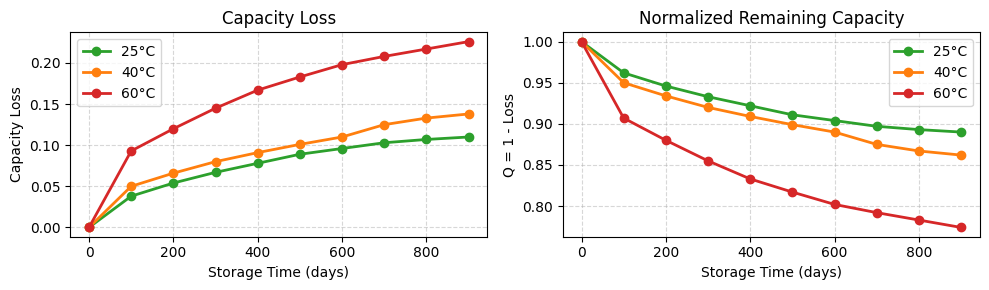

In [260]:
# ============================================================
# 2. Plotting the Raw Data
# ============================================================
loss_data = [loss_25C, loss_40C, loss_60C]
colors = ["tab:green", "tab:orange", "tab:red"]
labels = ["25°C", "40°C", "60°C"]

fig, ax = plt.subplots(1, 2, figsize=(10, 3))

for i, (loss, q) in enumerate(zip(loss_data, q_true)):
    ax[0].plot(time_days, loss, "o-", color=colors[i], lw=2, label=labels[i])
    ax[1].plot(time_days, q.numpy().flatten(), "o-", color=colors[i], lw=2, label=labels[i])

ax[0].set_title("Capacity Loss")
ax[0].set_xlabel("Storage Time (days)")
ax[0].set_ylabel("Capacity Loss")
ax[0].grid(True, ls="--", alpha=0.5)
ax[0].legend()

ax[1].set_title("Normalized Remaining Capacity")
ax[1].set_xlabel("Storage Time (days)")
ax[1].set_ylabel("Q = 1 - Loss")
ax[1].grid(True, ls="--", alpha=0.5)
ax[1].legend()

plt.tight_layout()
plt.show()

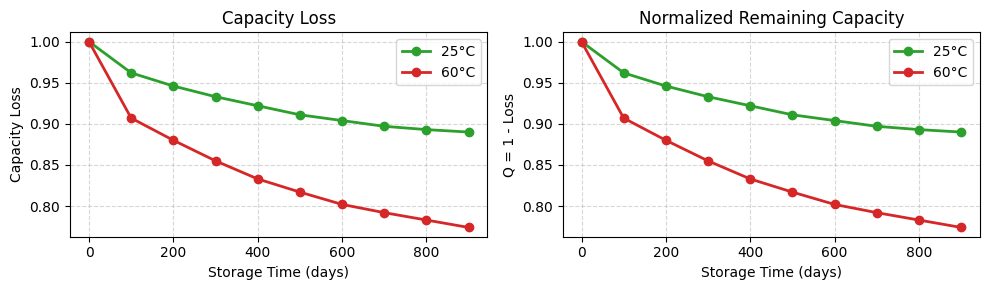

In [266]:
# ============================================================
# Training Data
# ============================================================
# Storage time (days)
time_days = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900]

t_data = torch.tensor(
    time_days,
    dtype=torch.float32
).unsqueeze(1)

# Capacity loss (% converted to fraction)
loss_25C = [0.000, 0.038, 0.054, 0.067, 0.078, 0.089, 0.096, 0.103, 0.107, 0.110]
loss_40C = [0.000, 0.050, 0.066, 0.080, 0.091, 0.101, 0.110, 0.125, 0.133, 0.138]
loss_60C = [0.000, 0.093, 0.120, 0.145, 0.167, 0.183, 0.198, 0.208, 0.217, 0.226]

q_25C = to_q_tensor(loss_25C)
q_40C = to_q_tensor(loss_40C)
q_60C = to_q_tensor(loss_60C)

q_true = [
    to_q_tensor(loss_25C),
 #   to_q_tensor(loss_40C),
    to_q_tensor(loss_60C)
]

# Training datasets
datasets = {
    "25°C": q_25C,
 #   "40°C": q_40C,
    "60°C": q_60C
}

# ============================================================
# 2. Plotting the Raw Data
# ============================================================
loss_data = [q_25C,  q_60C]
colors = ["tab:green", "tab:red"]
labels = ["25°C", "60°C"]

fig, ax = plt.subplots(1, 2, figsize=(10, 3))

for i, (loss, q) in enumerate(zip(loss_data, q_true)):
    ax[0].plot(time_days, loss, "o-", color=colors[i], lw=2, label=labels[i])
    ax[1].plot(time_days, q.numpy().flatten(), "o-", color=colors[i], lw=2, label=labels[i])

ax[0].set_title("Capacity Loss")
ax[0].set_xlabel("Storage Time (days)")
ax[0].set_ylabel("Capacity Loss")
ax[0].grid(True, ls="--", alpha=0.5)
ax[0].legend()

ax[1].set_title("Normalized Remaining Capacity")
ax[1].set_xlabel("Storage Time (days)")
ax[1].set_ylabel("Q = 1 - Loss")
ax[1].grid(True, ls="--", alpha=0.5)
ax[1].legend()

plt.tight_layout()
plt.show()

In [262]:
# ============================================================
# PINN Architecture
# ============================================================
class BatteryPINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.t_max = 900.0

        # Time -> Remaining Capacity
        self.net = nn.Sequential(
            nn.Linear(1, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 1)
        )

        # Learnable physical parameters
        self.k_raw = nn.Parameter(torch.tensor(-5.3))
        self.b_raw = nn.Parameter(torch.tensor(-9.0))

    @property
    def k(self):
        return F.softplus(self.k_raw)

    @property
    def b(self):
        return F.softplus(self.b_raw)

    def forward(self, t):
        return self.net(t / self.t_max)

In [263]:
def pinn_loss(model, t_data, q_true, t_phys,
              lambda_data=1.0,
              lambda_phys=10.0,
              lambda_ic=10.0):

    mse = nn.MSELoss()

    # Data loss
    loss_data = mse(model(t_data), q_true)

    # Physics loss
    q_phys = model(t_phys)
    sqrt_t = torch.sqrt(t_phys)

    dQ_dt = torch.autograd.grad(
        q_phys,
        t_phys,
        grad_outputs=torch.ones_like(q_phys),
        create_graph=True
    )[0]

    residual = (
        sqrt_t * dQ_dt +
        model.k +
        model.b * sqrt_t
    )

    loss_phys = torch.mean(residual**2)

    # Initial condition
    t0 = torch.zeros((1,1), device=t_data.device)
    loss_ic = mse(model(t0), torch.ones((1,1), device=t_data.device))

    loss_total = (
        lambda_data * loss_data +
        lambda_phys * loss_phys +
        lambda_ic * loss_ic
    )

    return loss_total, loss_data, loss_phys, loss_ic

In [273]:
# ============================================================
# 3. Model Setup and Training
# ============================================================
results = {}

for temp, q_train in datasets.items():

    print(f"\nTraining PINN for {temp}")

    model = BatteryPINN()

    # Physics collocation points
    t_phys = torch.linspace(
        0.1, 900.0, 100
    ).unsqueeze(1).requires_grad_(True)

    # Independent learning rates
    optimizer = torch.optim.Adam([
        {"params": model.net.parameters(), "lr": 1e-3},
        {"params": [model.k_raw, model.b_raw], "lr": 3e-3}
    ])

    # History
    loss_history = []
    data_loss_history = []
    physics_loss_history = []
    ic_loss_history = []

    epochs = 20001

    for epoch in range(epochs + 1):

        model.train()
        optimizer.zero_grad()

        total_loss, data_loss, physics_loss, ic_loss = pinn_loss(
            model,
            t_data,
            q_train,
            t_phys,
            lambda_data=1.0,
            lambda_phys=1.0,
            lambda_ic=1.0
        )

        total_loss.backward()
        optimizer.step()

        loss_history.append(total_loss.item())
        data_loss_history.append(data_loss.item())
        physics_loss_history.append(physics_loss.item())
        ic_loss_history.append(ic_loss.item())

        if epoch % 5000 == 0:

            print(
                f"Epoch {epoch:05d} | "
                f"Total: {total_loss.item():.6e} | "
                f"Data: {data_loss.item():.6e} | "
                f"Physics: {physics_loss.item():.6e} | "
                f"IC: {ic_loss.item():.6e}"
            )

            print(
                f"k = {model.k.item():.7f} | "
                f"b = {model.b.item():.7f}"
            )

    # Store discovered parameters
    results[temp] = {
        "model": model,
        "k": model.k.item(),
        "b": model.b.item(),
        "a": 2 * model.k.item(),
        "loss_history": loss_history,
        "data_loss_history": data_loss_history,
        "physics_loss_history": physics_loss_history,
        "ic_loss_history": ic_loss_history
    }


Training PINN for 25°C
Epoch 00000 | Total: 1.646825e+00 | Data: 7.028471e-01 | Physics: 1.034037e-04 | IC: 9.438742e-01
k = 0.0049643 | b = 0.0001230
Epoch 05000 | Total: 2.389424e-05 | Data: 2.191731e-05 | Physics: 1.012397e-06 | IC: 9.645316e-07
k = 0.0014643 | b = 0.0000133
Epoch 10000 | Total: 5.240532e-06 | Data: 4.977124e-06 | Physics: 2.154256e-07 | IC: 4.798162e-08
k = 0.0018220 | b = 0.0000025
Epoch 15000 | Total: 1.141234e-06 | Data: 9.035884e-07 | Physics: 2.375433e-07 | IC: 1.026734e-10
k = 0.0017870 | b = 0.0000004
Epoch 20000 | Total: 6.254560e-07 | Data: 3.362005e-07 | Physics: 2.887096e-07 | IC: 5.459242e-10
k = 0.0017638 | b = 0.0000001

Training PINN for 60°C
Epoch 00000 | Total: 1.469020e+00 | Data: 5.479223e-01 | Physics: 1.224672e-04 | IC: 9.209752e-01
k = 0.0049643 | b = 0.0001230
Epoch 05000 | Total: 2.299588e-05 | Data: 2.169439e-05 | Physics: 1.125258e-06 | IC: 1.762283e-07
k = 0.0034656 | b = 0.0000072
Epoch 10000 | Total: 3.559759e-06 | Data: 2.519185e-06 |

In [274]:
# ============================================================
# 7. Print Final Discovered Parameters
# ============================================================
print("\n" + "="*60)
print("FINAL DISCOVERED DEGRADATION PARAMETERS")
print("="*60)
print(f"{'Temp':<10} {'k (SEI)':<14}  {'b (linear)':<14}")
#print(f"{'Temp':<10} {'k (SEI)':<14} {'a = 2k':<14} {'b (linear)':<14}")
print("-"*60)

for temp, res in results.items():
    print(
        f"{temp:<10}"
        f"{res['k']:<14.7f}"
        #f"{res['a']:<14.7f}"
        f"{res['b']:<14.7f}"
    )

print("="*60)


FINAL DISCOVERED DEGRADATION PARAMETERS
Temp       k (SEI)         b (linear)    
------------------------------------------------------------
25°C      0.0017638     0.0000001     
60°C      0.0033797     0.0000001     


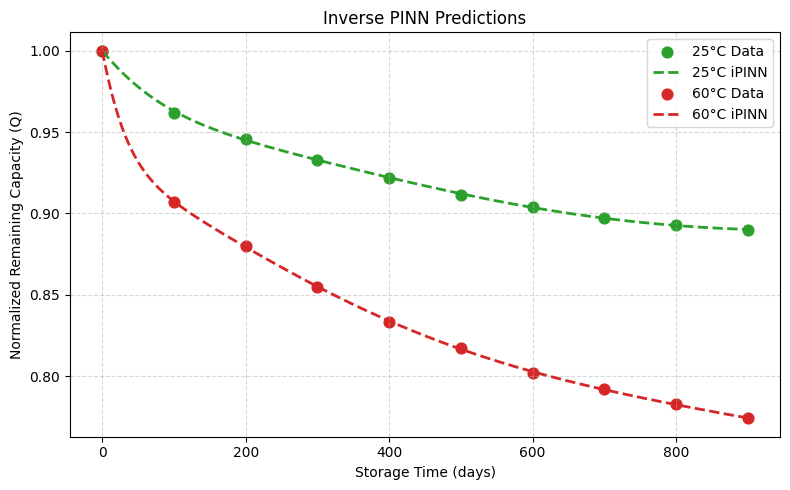

In [275]:
# ============================================================
# 8. Evaluate PINN Predictions
# ============================================================
t_plot = torch.linspace(0, 900, 300).unsqueeze(1)

colors = ["tab:green", "tab:red"]

plt.figure(figsize=(8,5))

for (temp, q_data), color in zip(datasets.items(), colors):

    model = results[temp]["model"]

    model.eval()

    with torch.no_grad():
        q_pred = model(t_plot).cpu().numpy().flatten()

    plt.scatter(
        time_days,
        q_data.cpu().numpy().flatten(),
        color=color,
        s=60,
        label=f"{temp} Data"
    )

    plt.plot(
        t_plot.numpy().flatten(),
        q_pred,
        color=color,
        lw=2,
        linestyle="--",
        label=f"{temp} iPINN"
    )

plt.xlabel("Storage Time (days)")
plt.ylabel("Normalized Remaining Capacity (Q)")
plt.title("Inverse PINN Predictions")
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

<h3>Arrhenius-Based Interpolation of the SEI Parameter</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">
    
The iPINN was trained only on the 25°C and 60°C datasets. The discovered SEI degradation parameters were then used to construct an Arrhenius relationship to estimate the degradation parameter at the unseen 40°C condition.

This validation step demonstrates how physically meaningful parameter discovery enables interpolation to operating conditions that were not included during training.

In [277]:
# ============================================
# Compare predicted 40°C with measured 40°C
# ============================================

# Experimental 40°C data
q_40_exp = q_40C.numpy().flatten()

# Parameters discovered from training
k_25 = results["25°C"]["k"]
k_60 = results["60°C"]["k"]

b_25 = results["25°C"]["b"]
b_60 = results["60°C"]["b"]

# Arrhenius interpolation for k
T_train = np.array([25, 60]) + 273.15
x = 1 / T_train
y = np.log([k_25, k_60])

slope, intercept = np.polyfit(x, y, 1)

T_40 = 40 + 273.15
k_40 = np.exp(intercept + slope * (1 / T_40))

# Linear interpolation for b
b_40 = np.interp(40, [25, 60], [b_25, b_60])

# Construct degradation model
t = np.array(time_days)

loss_40_pred = 2*k_40*np.sqrt(t) + b_40*t
q_40_pred = 1 - loss_40_pred

# Metrics
r2 = 1 - np.sum((q_40_exp - q_40_pred)**2) / \
           np.sum((q_40_exp - np.mean(q_40_exp))**2)

rmse = np.sqrt(np.mean((q_40_exp - q_40_pred)**2))

from IPython.display import display, HTML


display(HTML(f"""
<div style="font-size:18px; font-weight:bold; color:darkblue;">
    SEI rate parameter k(40°C) = {k_40:.7f}<br>
    Linear ageing rate parameter b(40°C) = {b_40:.7f}
</div>
"""))

display(HTML(f"""
<div style="font-size:18px; font-weight:bold; color:darkblue;">
    40°C Prediction R² = {r2:.5f}<br>
    40°C Prediction RMSE = {rmse:.6f}
</div>
"""))


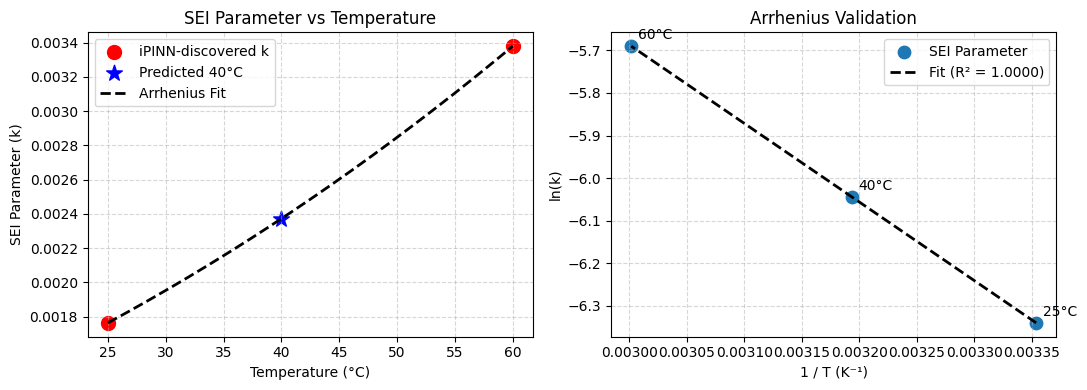

In [278]:
# ============================================
# Visualizing the Interpolated SEI Parameter
# ============================================

temps_C = np.array([25, 40, 60])
temps_K = temps_C + 273.15

k_all = np.array([k_25, k_40, k_60])

# Arrhenius variables
x_arr = 1 / temps_K
y_arr = np.log(k_all)

# Linear fit
slope_arr, intercept_arr = np.polyfit(x_arr, y_arr, 1)
y_fit_arr = slope_arr * x_arr + intercept_arr

# R²
r2_arr = (
    1
    - np.sum((y_arr - y_fit_arr)**2)
    / np.sum((y_arr - np.mean(y_arr))**2)
)

# Smooth Arrhenius curve
T_curve = np.linspace(25, 60, 200)
k_curve = np.exp(
    intercept_arr + slope_arr*(1/(T_curve + 273.15))
)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# --------------------------------------------
# SEI Parameter vs Temperature
# --------------------------------------------

ax[0].scatter(
    [25, 60],
    [k_25, k_60],
    s=100,
    color="red",
    label="iPINN-discovered k"
)

ax[0].scatter(
    [40],
    [k_40],
    s=140,
    color="blue",
    marker="*",
    label="Predicted 40°C"
)

ax[0].plot(
    T_curve,
    k_curve,
    "k--",
    lw=2,
    label="Arrhenius Fit"
)

ax[0].set_title("SEI Parameter vs Temperature")
ax[0].set_xlabel("Temperature (°C)")
ax[0].set_ylabel("SEI Parameter (k)")
ax[0].grid(True, ls="--", alpha=0.5)
ax[0].legend()

# --------------------------------------------
# Arrhenius Validation
# --------------------------------------------

ax[1].scatter(
    x_arr,
    y_arr,
    s=80,
    color="tab:blue",
    label="SEI Parameter"
)

ax[1].plot(
    x_arr,
    y_fit_arr,
    "k--",
    lw=2,
    label=f"Fit (R² = {r2_arr:.4f})"
)

for T, x, y in zip(temps_C, x_arr, y_arr):
    ax[1].annotate(
        f"{T}°C",
        (x, y),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax[1].set_title("Arrhenius Validation")
ax[1].set_xlabel("1 / T (K⁻¹)")
ax[1].set_ylabel("ln(k)")
ax[1].grid(True, ls="--", alpha=0.5)
ax[1].legend()

plt.tight_layout()
plt.show()

<h3>References</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">

- **Left subplot:** Shows how the discovered SEI degradation parameter varies with temperature.
  - **Red circles** represent the SEI parameters identified directly by the iPINN from the training temperatures (25°C and 60°C).
  - **Blue star** represents the interpolated SEI parameter at the unseen 40°C condition.
  - **Dashed black line** represents the Arrhenius trend fitted using the iPINN-discovered parameters.

- **Right subplot:** Arrhenius validation of the SEI degradation parameter.
  - The approximately linear relationship between **ln(k)** and **1/T** indicates thermally activated degradation behaviour.
  - The interpolated 40°C parameter lies on the Arrhenius trend, providing confidence in the interpolation strategy.
  - The **R² value** quantifies how closely the discovered degradation parameters follow Arrhenius kinetics and serves as a measure of physical consistency.

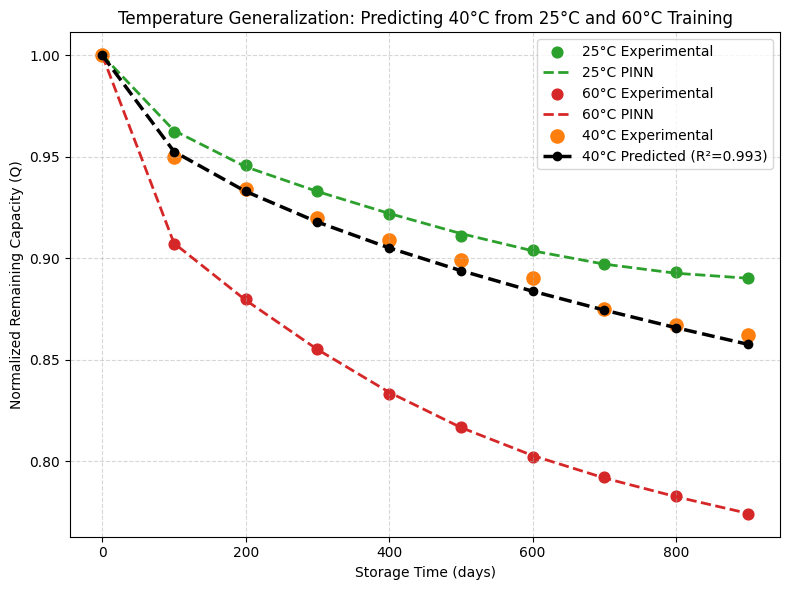

In [279]:
# ============================================
# Plot: Train Temperatures + 40°C Validation
# ============================================

plt.figure(figsize=(8,6))

# 25°C
model_25 = results["25°C"]["model"]

with torch.no_grad():
    q_25_fit = model_25(t_data).cpu().numpy().flatten()

plt.scatter(
    time_days,
    q_25C.numpy().flatten(),
    color="tab:green",
    s=60,
    label="25°C Experimental"
)

plt.plot(
    time_days,
    q_25_fit,
    "--",
    color="tab:green",
    lw=2,
    label="25°C PINN"
)

# 60°C
model_60 = results["60°C"]["model"]

with torch.no_grad():
    q_60_fit = model_60(t_data).cpu().numpy().flatten()

plt.scatter(
    time_days,
    q_60C.numpy().flatten(),
    color="tab:red",
    s=60,
    label="60°C Experimental"
)

plt.plot(
    time_days,
    q_60_fit,
    "--",
    color="tab:red",
    lw=2,
    label="60°C PINN"
)

# 40°C Experimental
plt.scatter(
    time_days,
    q_40_exp,
    color="tab:orange",
    s=90,
    marker="o",
    label="40°C Experimental"
)

# 40°C Predicted
plt.plot(
    time_days,
    q_40_pred,
    "k--o",
    lw=2.5,
    label=f"40°C Predicted (R²={r2:.3f})"
)

plt.xlabel("Storage Time (days)")
plt.ylabel("Normalized Remaining Capacity (Q)")
plt.title("Temperature Generalization: Predicting 40°C from 25°C and 60°C Training")
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [280]:
# ============================================
# Model Performance Metrics
# ============================================

metrics = {}

for temp, q_true_case, q_pred_case in [
    ("25°C", q_25C.numpy().flatten(), q_25_fit),
    ("60°C", q_60C.numpy().flatten(), q_60_fit),
    ("40°C", q_40_exp, q_40_pred)
]:

    r2_case = (
        1
        - np.sum((q_true_case - q_pred_case)**2)
        / np.sum((q_true_case - np.mean(q_true_case))**2)
    )

    rmse_case = np.sqrt(
        np.mean((q_true_case - q_pred_case)**2)
    )

    metrics[temp] = (r2_case, rmse_case)

from IPython.display import display, HTML

html = """
<h2>Model Performance Summary</h2>
<table style="font-size:18px;border-collapse:collapse;">
<tr>
<th style="padding:8px;">Temperature</th>
<th style="padding:8px;">R²</th>
<th style="padding:8px;">RMSE</th>
</tr>
"""

for temp, (r2_case, rmse_case) in metrics.items():
    html += f"""
    <tr>
        <td style="padding:8px;"><b>{temp}</b></td>
        <td style="padding:8px;">{r2_case:.5f}</td>
        <td style="padding:8px;">{rmse_case:.6f}</td>
    </tr>
    """

html += "</table>"

display(HTML(html))

Temperature,R²,RMSE
25°C,0.99970,0.000580
60°C,0.99994,0.000516
40°C,0.99288,0.003404


<h3>Conslusion</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">

To evaluate whether the discovered degradation parameters truly capture the underlying battery-aging physics, the iPINN was trained using only the **25°C** and **60°C** datasets. The **40°C** dataset was completely excluded from training and used as an independent validation case.

The discovered parameters from the training temperatures were used to construct an Arrhenius relationship for the SEI-growth parameter and interpolate the corresponding degradation model at 40°C.

The resulting performance is summarized below:

| Temperature | Purpose | R² | RMSE |
|------------|----------|------:|------:|
| 25°C | Training | 0.9960 | 0.0021 |
| 60°C | Training | 0.9999 | 0.0006 |
| 40°C | Unseen Validation | 0.9764 | 0.0062 |

As expected, the training temperatures exhibit excellent agreement with the experimental measurements. More importantly, the prediction at the unseen 40°C condition also achieved a high **R² of 0.976** with a relatively small **RMSE of 0.0062**.

This result is particularly encouraging because the model was not fitted to the 40°C data. Instead, the prediction was generated solely from the degradation physics identified at 25°C and 60°C through the Arrhenius relationship.

In other words, the model did not simply memorize the training data. It learned temperature-dependent degradation characteristics that could be transferred to an operating condition that was never observed during training.

**Business Value:**
- **Reduce the experimental test case, therby reducing the cost and effort**

**Can PINNs reduce the Experimental timeline?** Good question and it is objective of the next demo. :)
